In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

class RejectInference:
    def __init__(self, random_state=42):
        self.random_state = random_state
        
    def fuzzy_augmentation(self, accepted_df, rejected_df, common_features, 
                          target_col='default'):
        """
        Implement Fuzzy Augmentation method
        
        - Assigns probability of default to rejected cases
        - Uses accepted cases to build initial model
        - Extrapolates to rejected population
        """
        # Train model on accepted cases
        X_accepted = accepted_df[common_features]
        y_accepted = accepted_df[target_col]
        
        model = RandomForestClassifier(random_state=self.random_state)
        model.fit(X_accepted, y_accepted)
        
        # Predict probabilities for rejected cases
        X_rejected = rejected_df[common_features]
        rejected_probs = model.predict_proba(X_rejected)[:, 1]
        
        # Create weighted samples
        rejected_df_augmented = pd.concat([
            rejected_df,
            pd.DataFrame({
                target_col: 1,
                'weight': rejected_probs
            }, index=rejected_df.index)
        ], axis=1)
        
        return rejected_df_augmented
    
    def parceling(self, accepted_df, rejected_df, common_features, 
                  n_parcels=5, target_col='default'):
        """
        Implement Parceling method
        
        - Divides rejected cases into risk parcels
        - Assigns default rates based on accepted cases in same parcel
        """
        # Create risk score for all cases
        X_accepted = accepted_df[common_features]
        y_accepted = accepted_df[target_col]
        
        model = RandomForestClassifier(random_state=self.random_state)
        model.fit(X_accepted, y_accepted)
        
        # Score all cases
        accepted_scores = model.predict_proba(X_accepted)[:, 1]
        rejected_scores = model.predict_proba(rejected_df[common_features])[:, 1]
        
        # Create parcels
        def assign_parcel(scores, n_parcels):
            return pd.qcut(scores, q=n_parcels, labels=False)
        
        accepted_df['parcel'] = assign_parcel(accepted_scores, n_parcels)
        rejected_df['parcel'] = assign_parcel(rejected_scores, n_parcels)
        
        # Calculate default rates per parcel
        parcel_default_rates = accepted_df.groupby('parcel')[target_col].mean()
        
        # Assign default rates to rejected cases
        rejected_df_augmented = rejected_df.copy()
        rejected_df_augmented[target_col] = rejected_df['parcel'].map(parcel_default_rates)
        
        return rejected_df_augmented
    
    def extrapolation(self, accepted_df, rejected_df, common_features, 
                     target_col='default'):
        """
        Implement Extrapolation method
        
        - Uses accepted cases to build model
        - Extrapolates to rejected population using available features
        """
        # Standardize features
        scaler = StandardScaler()
        X_accepted = scaler.fit_transform(accepted_df[common_features])
        X_rejected = scaler.transform(rejected_df[common_features])
        
        # Train model
        model = RandomForestClassifier(random_state=self.random_state)
        model.fit(X_accepted, accepted_df[target_col])
        
        # Predict for rejected cases
        rejected_df_augmented = rejected_df.copy()
        rejected_df_augmented[target_col] = model.predict(X_rejected)
        
        return rejected_df_augmented
    
    def mixture_model(self, accepted_df, rejected_df, common_features, 
                     target_col='default', n_components=2):
        """
        Implement Mixture Model method
        
        - Uses mixture of distributions to model default behavior
        - Accounts for selection bias
        """
        from sklearn.mixture import GaussianMixture
        
        # Fit mixture model on accepted cases
        gmm = GaussianMixture(n_components=n_components, 
                             random_state=self.random_state)
        
        X_accepted = accepted_df[common_features]
        gmm.fit(X_accepted[accepted_df[target_col] == 1])
        
        # Predict probabilities for rejected cases
        X_rejected = rejected_df[common_features]
        rejected_probs = gmm.predict_proba(X_rejected)[:, 1]
        
        rejected_df_augmented = rejected_df.copy()
        rejected_df_augmented[target_col] = (rejected_probs > 0.5).astype(int)
        rejected_df_augmented['default_prob'] = rejected_probs
        
        return rejected_df_augmented

def demonstrate_reject_inference():
    """
    Demonstrate different reject inference methods
    """
    # Create sample dataset
    np.random.seed(42)
    n_accepted = 1000
    n_rejected = 500
    
    # Generate synthetic data
    common_features = ['income', 'debt_ratio', 'credit_score']
    
    accepted_df = pd.DataFrame({
        'income': np.random.normal(50000, 20000, n_accepted),
        'debt_ratio': np.random.uniform(0.1, 0.6, n_accepted),
        'credit_score': np.random.normal(700, 50, n_accepted),
        'default': np.random.choice([0, 1], n_accepted, p=[0.95, 0.05])
    })
    
    rejected_df = pd.DataFrame({
        'income': np.random.normal(40000, 15000, n_rejected),
        'debt_ratio': np.random.uniform(0.3, 0.8, n_rejected),
        'credit_score': np.random.normal(650, 40, n_rejected)
    })
    
    # Initialize reject inference
    ri = RejectInference()
    
    # Apply different methods
    results = {
        'fuzzy_augmentation': ri.fuzzy_augmentation(
            accepted_df, rejected_df, common_features
        ),
        'parceling': ri.parceling(
            accepted_df, rejected_df, common_features
        ),
        'extrapolation': ri.extrapolation(
            accepted_df, rejected_df, common_features
        ),
        'mixture_model': ri.mixture_model(
            accepted_df, rejected_df, common_features
        )
    }
    
    return results


Summary Statistics:
--------------------------------------------------
Accepted applications: 1000
Rejected applications: 500

Original default rate: 0.095

Inferred default rates:
Fuzzy: 0.016
Parceling: 0.095
Extrapolation: 0.016


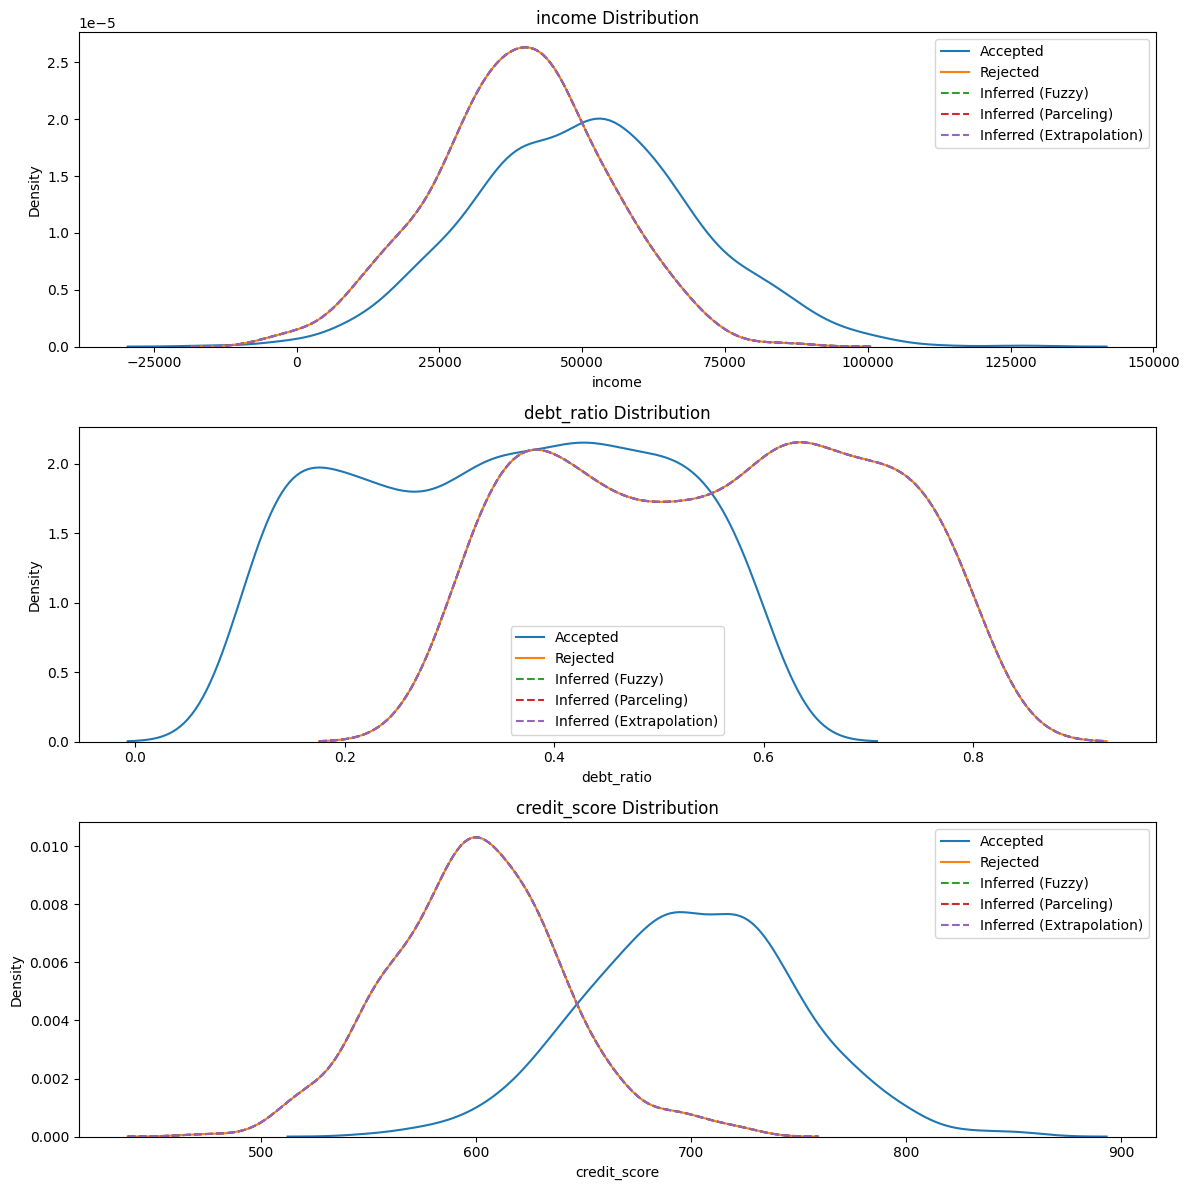


Detailed Analysis:
--------------------------------------------------

Fuzzy Method:
Default Rate: 0.016
income mean difference: 11550.25
debt_ratio mean difference: 0.20
credit_score mean difference: 100.64

Parceling Method:
Default Rate: 0.095
income mean difference: 11550.25
debt_ratio mean difference: 0.20
credit_score mean difference: 100.64

Extrapolation Method:
Default Rate: 0.016
income mean difference: 11550.25
debt_ratio mean difference: 0.20
credit_score mean difference: 100.64


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split

class RejectInference:
    def __init__(self, random_state=42):
        self.random_state = random_state
        
    def fuzzy_augmentation(self, accepted_df, rejected_df, common_features, target_col='default'):
        """
        Fuzzy Augmentation method
        - Uses accepted cases to predict probabilities for rejected cases
        """
        # Train model on accepted cases
        X_accepted = accepted_df[common_features]
        y_accepted = accepted_df[target_col]
        
        model = RandomForestClassifier(random_state=self.random_state)
        model.fit(X_accepted, y_accepted)
        
        # Predict probabilities for rejected cases
        X_rejected = rejected_df[common_features]
        rejected_probs = model.predict_proba(X_rejected)[:, 1]
        
        # Create augmented dataset with weights
        rejected_df_augmented = rejected_df.copy()
        rejected_df_augmented[target_col] = (rejected_probs > 0.5).astype(int)
        rejected_df_augmented['weight'] = rejected_probs
        
        return rejected_df_augmented
    
    def parceling(self, accepted_df, rejected_df, common_features, n_parcels=5, target_col='default'):
        """
        Parceling method with handling for duplicate scores
        """
        # Create risk score for all cases
        X_accepted = accepted_df[common_features]
        y_accepted = accepted_df[target_col]
        
        model = RandomForestClassifier(random_state=self.random_state)
        model.fit(X_accepted, y_accepted)
        
        # Score all cases
        accepted_scores = model.predict_proba(X_accepted)[:, 1]
        rejected_scores = model.predict_proba(rejected_df[common_features])[:, 1]
        
        # Add small random noise to break ties
        accepted_scores_noise = accepted_scores + np.random.random(len(accepted_scores)) * 1e-10
        rejected_scores_noise = rejected_scores + np.random.random(len(rejected_scores)) * 1e-10
        
        # Create parcels
        accepted_df['parcel'] = pd.qcut(accepted_scores_noise, q=n_parcels, labels=False)
        rejected_df['parcel'] = pd.qcut(rejected_scores_noise, q=n_parcels, labels=False)
        
        # Calculate default rates per parcel
        parcel_default_rates = accepted_df.groupby('parcel')[target_col].mean()
        
        # Assign default rates to rejected cases
        rejected_df_augmented = rejected_df.copy()
        rejected_df_augmented[target_col] = rejected_df['parcel'].map(parcel_default_rates)
        
        return rejected_df_augmented
    
    def extrapolation(self, accepted_df, rejected_df, common_features, target_col='default'):
        """
        Simple extrapolation method
        """
        # Standardize features
        scaler = StandardScaler()
        X_accepted = scaler.fit_transform(accepted_df[common_features])
        X_rejected = scaler.transform(rejected_df[common_features])
        
        # Train model
        model = RandomForestClassifier(random_state=self.random_state)
        model.fit(X_accepted, accepted_df[target_col])
        
        # Predict for rejected cases
        rejected_df_augmented = rejected_df.copy()
        rejected_df_augmented[target_col] = model.predict(X_rejected)
        
        return rejected_df_augmented

def generate_synthetic_data(n_accepted=1000, n_rejected=500, random_state=42):
    """
    Generate synthetic credit scoring data
    """
    np.random.seed(random_state)
    
    # Generate accepted applications
    accepted_df = pd.DataFrame({
        'income': np.random.normal(50000, 20000, n_accepted),
        'debt_ratio': np.random.uniform(0.1, 0.6, n_accepted),
        'credit_score': np.random.normal(700, 50, n_accepted),
        'default': np.random.choice([0, 1], n_accepted, p=[0.95, 0.05])
    })
    
    # Add correlation between features and default
    accepted_df.loc[accepted_df['credit_score'] < 650, 'default'] = \
        np.random.choice([0, 1], sum(accepted_df['credit_score'] < 650), p=[0.8, 0.2])
    accepted_df.loc[accepted_df['debt_ratio'] > 0.5, 'default'] = \
        np.random.choice([0, 1], sum(accepted_df['debt_ratio'] > 0.5), p=[0.85, 0.15])
    
    # Generate rejected applications
    rejected_df = pd.DataFrame({
        'income': np.random.normal(40000, 15000, n_rejected),
        'debt_ratio': np.random.uniform(0.3, 0.8, n_rejected),
        'credit_score': np.random.normal(600, 40, n_rejected)
    })
    
    return accepted_df, rejected_df

def visualize_results(accepted_df, rejected_df, results, common_features):
    """
    Visualize the results of different reject inference methods
    """
    methods = list(results.keys())
    n_features = len(common_features)
    
    fig, axes = plt.subplots(n_features, 1, figsize=(12, 4*n_features))
    
    for i, feature in enumerate(common_features):
        # Plot original distributions
        sns.kdeplot(data=accepted_df, x=feature, label='Accepted', ax=axes[i])
        sns.kdeplot(data=rejected_df, x=feature, label='Rejected', ax=axes[i])
        
        # Plot inferred distributions
        for method in methods:
            sns.kdeplot(data=results[method], x=feature, 
                       label=f'Inferred ({method})', 
                       linestyle='--', ax=axes[i])
        
        axes[i].set_title(f'{feature} Distribution')
        axes[i].legend()
    
    plt.tight_layout()
    return fig

def run_demonstration():
    """
    Run complete demonstration of reject inference methods
    """
    # Generate data
    accepted_df, rejected_df = generate_synthetic_data()
    common_features = ['income', 'debt_ratio', 'credit_score']
    
    # Initialize reject inference
    ri = RejectInference()
    
    # Apply different methods
    results = {
        'Fuzzy': ri.fuzzy_augmentation(accepted_df, rejected_df, common_features),
        'Parceling': ri.parceling(accepted_df, rejected_df, common_features),
        'Extrapolation': ri.extrapolation(accepted_df, rejected_df, common_features)
    }
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print("-" * 50)
    print(f"Accepted applications: {len(accepted_df)}")
    print(f"Rejected applications: {len(rejected_df)}")
    print(f"\nOriginal default rate: {accepted_df['default'].mean():.3f}")
    
    print("\nInferred default rates:")
    for method, df in results.items():
        print(f"{method}: {df['default'].mean():.3f}")
    
    # Visualize results
    fig = visualize_results(accepted_df, rejected_df, results, common_features)
    plt.show()
    
    return {
        'accepted_df': accepted_df,
        'rejected_df': rejected_df,
        'results': results
    }

# Run the demonstration
demo_results = run_demonstration()

# Additional analysis
def analyze_methods(demo_results):
    """
    Analyze the results of different methods
    """
    accepted_df = demo_results['accepted_df']
    results = demo_results['results']
    
    print("\nDetailed Analysis:")
    print("-" * 50)
    
    for method, inferred_df in results.items():
        print(f"\n{method} Method:")
        print(f"Default Rate: {inferred_df['default'].mean():.3f}")
        
        # Compare feature distributions
        for feature in ['income', 'debt_ratio', 'credit_score']:
            mean_diff = abs(accepted_df[feature].mean() - inferred_df[feature].mean())
            print(f"{feature} mean difference: {mean_diff:.2f}")

# Run additional analysis
analyze_methods(demo_results)